# Lab: Hồi quy Logistic (Logistic Regression)

## 1. Vì sao không dùng Linear Regression cho phân loại?

Linear Regression cho output là một số thực bất kỳ, có thể âm, có thể lớn hơn 1. Trong phân loại nhị phân, ta muốn output nằm trong $[0, 1]$ để hiểu là *xác suất* thuộc lớp 1.

Giải pháp: đưa $w^T x + b$ qua hàm sigmoid để ép về $[0, 1]$:
$$
\hat{p}(x) = \sigma(w^T x + b) = \frac{1}{1 + e^{-(w^T x + b)}}
$$

Đây là **Logistic Regression**: nghe tên thì giống regression nhưng thực chất là **classifier**.

## 2. Hàm Sigmoid

$$\sigma(z) = \frac{1}{1 + e^{-z}}$$

Tính chất:
- $\sigma(0) = 0.5$.
- $\sigma(z) \to 1$ khi $z \to +\infty$, $\sigma(z) \to 0$ khi $z \to -\infty$.
- Đạo hàm có dạng gọn: $\sigma'(z) = \sigma(z)(1 - \sigma(z))$.

Sau khi có $\hat{p}$, dự đoán nhãn theo ngưỡng (mặc định 0.5):
$$\hat{y} = \begin{cases}1 & \hat{p} \ge 0.5 \\ 0 & \hat{p} < 0.5\end{cases}$$

## 3. Hàm mất mát: Binary Cross-Entropy

Vì sao không dùng MSE? MSE + sigmoid cho một mặt mất mát không lồi, với những vùng gần như phẳng nơi gradient tắt hẳn. Hơn nữa, gradient gần 0 ở vùng $\hat{p}$ gần 0 hoặc 1 (sigmoid bão hoà).

Logistic Regression dùng **Binary Cross-Entropy (BCE)**:
$$
L = -\frac{1}{N}\sum_{i=1}^{N}\Big[y_i \log \hat{p}_i + (1 - y_i) \log(1 - \hat{p}_i)\Big]
$$

Diễn giải:
- Nếu $y_i = 1$: muốn $\hat{p}_i$ gần 1, tức $-\log \hat{p}_i$ nhỏ.
- Nếu $y_i = 0$: muốn $\hat{p}_i$ gần 0, tức $-\log(1 - \hat{p}_i)$ nhỏ.

BCE lồi theo $w$, nên Gradient Descent đảm bảo về cực tiểu toàn cục.

## 4. Công thức gradient gọn

Khi tổ hợp Sigmoid + BCE, gradient có dạng đơn giản:
$$\frac{\partial L}{\partial w_j} = \frac{1}{N}\sum_{i=1}^{N}(\hat{p}_i - y_i) \cdot x_{i,j}$$

Nghĩa là: gradient = (sai số) × (input). Đây cũng chính là gradient của Linear Regression với MSE, chỉ khác ở chỗ $\hat{p}$ là sigmoid thay vì linear. Dạng gradient này xuất hiện lại ở tầng cuối của các mạng neural phân loại.

---

## 0. Thử dùng Linear Regression cho phân loại: hỏng ở đâu?

Cách tự nhiên nhất khi mới học: gán nhãn 0/1 rồi chạy thẳng `LinearRegression`, ai lớn hơn 0.5 thì cho là lớp 1. Nghe hợp lý. Nhưng nó hỏng ở ba chỗ:

![Vì sao không dùng Linear Regression cho phân loại](images/01_vi_sao_khong_dung_linear.png)

*Trái: đường thẳng chui xuống dưới 0 và vọt lên trên 1 (vùng tô đỏ), và những giá trị đó không thể đọc là xác suất. Giữa: thêm 5 điểm lớp 1 ở rất xa (bản thân chúng vẫn được đoán đúng), đường thẳng bị kéo thoải ra, ngưỡng trôi từ 4.1 sang 5.2 và 4 điểm lớp 1 ban đầu bị phân loại sai (dấu x) dù dữ liệu của chúng không hề thay đổi. Phải: Logistic Regression trên đúng bộ dữ liệu có outlier đó, ngưỡng vẫn đứng yên ở 3.81, sai 0/40.*

| Vấn đề | Linear Regression | Logistic Regression |
|---|---|---|
| Output ngoài $[0,1]$ | Có, vô nghĩa khi cần xác suất | Không bao giờ, nhờ sigmoid |
| Điểm ở xa kéo lệch ranh giới | Rất mạnh (MSE phạt bình phương) | Yếu (điểm đã đúng chắc chắn thì gradient $\approx 0$) |
| Giả định về nhiễu | Gaussian, sai với dữ liệu nhị phân | Bernoulli, đúng với dữ liệu nhị phân |

Cái thứ ba là gốc rễ. Nhãn 0/1 tuân theo phân phối **Bernoulli**, không phải Gaussian. Linear Regression giả định sai ngay từ đầu; Logistic Regression giả định đúng. Mọi thứ khác chỉ là hệ quả.

## 2b. Sigmoid: đọc kỹ từng tính chất

![Hàm sigmoid và đạo hàm](images/02_ham_sigmoid.png)

*Trái: sigmoid ép trục số thực vô hạn về khoảng $(0,1)$; hai đầu là **vùng bão hoà**: thay đổi $z$ rất nhiều mà $\hat{p}$ gần như đứng yên. Phải: đạo hàm $\sigma'(z)=\sigma(z)(1-\sigma(z))$ đạt cực đại chỉ 0.25 tại $z=0$ và tắt rất nhanh về hai phía.*

Bốn tính chất cần nhớ:

1. **Đối xứng:** $\sigma(-z) = 1 - \sigma(z)$. Nên $\hat{p}(y=0) = \sigma(-z)$, nên chỉ cần một hàm cho cả hai lớp.
2. **Đạo hàm gọn:** $\sigma'(z) = \sigma(z)\big(1 - \sigma(z)\big)$. Tính $\sigma$ một lần là có luôn đạo hàm, rất rẻ khi backprop.
3. **Bão hoà:** khi $|z| > 5$ thì $\sigma' < 0.007$. Gradient gần như bằng 0, nên tham số gần như không cập nhật nữa.
4. **Hàm ngược là logit:** $\sigma^{-1}(p) = \ln\frac{p}{1-p}$.

Tính chất 3 chính là nguồn gốc của **vanishing gradient**, hiện tượng khiến mạng neural sâu dùng sigmoid rất khó train, và là lý do ReLU ra đời (ta sẽ gặp lại ở Lab 09).

Một lưu ý số học: `1/(1+np.exp(-z))` bị tràn khi `z` rất âm (`exp(1000) = inf`). Trong lab ta dùng `np.clip(z, -500, 500)`. Thư viện thật dùng công thức ổn định theo dấu của $z$, hoặc `scipy.special.expit`.

## 2c. Odds, logit và cách đọc hệ số $w_j$

![Odds và logit](images/03_odds_va_logit.png)

Phần này hay bị bỏ qua, nhưng chính nó khiến Logistic Regression được ưa chuộng trong y học và tài chính: hệ số của nó diễn giải được.

- **Odds** (tỷ lệ cược): $\text{odds} = \dfrac{p}{1-p}$. Ví dụ $p = 0.8$ cho odds $= 4$, nghĩa là "khả năng xảy ra gấp 4 lần không xảy ra".
- **Logit** = $\ln(\text{odds})$, kéo $[0,1]$ ra thành $(-\infty, +\infty)$.

Viết ngược lại mô hình:
$$
\ln \frac{p}{1-p} = w^Tx + b
$$

Nói cách khác, Logistic Regression là hồi quy tuyến tính trên thang log-odds. Từ đó suy ra cách đọc hệ số:

Khi $x_j$ tăng thêm 1 đơn vị (các biến khác giữ nguyên), odds nhân lên $e^{w_j}$ lần. Đại lượng $e^{w_j}$ gọi là **Odds Ratio (OR)**.

| $w_j$ | $e^{w_j}$ | Diễn giải |
|---|---|---|
| $0$ | 1.00 | Feature không ảnh hưởng |
| $0.69$ | 2.00 | Tăng 1 đơn vị, odds gấp đôi |
| $-0.69$ | 0.50 | Tăng 1 đơn vị, odds giảm một nửa |
| $1.10$ | 3.00 | Tăng 1 đơn vị, odds gấp 3 |

Ví dụ báo cáo y khoa: "Hút thuốc có $w = 1.4$, tức $OR = e^{1.4} \approx 4.05$: người hút thuốc có odds mắc bệnh cao gấp 4 lần người không hút, sau khi đã hiệu chỉnh các yếu tố khác."

> **Lưu ý:** (1) OR nói về odds, không phải xác suất; chỉ khi bệnh hiếm ($p$ nhỏ) thì OR mới xấp xỉ risk ratio. (2) Nếu đã `StandardScaler`, hệ số ứng với "tăng 1 độ lệch chuẩn", không phải 1 đơn vị gốc. Muốn diễn giải theo đơn vị gốc thì chia lại cho $\sigma_j$.

## 3b. BCE đến từ đâu? Suy ra từ hợp lý cực đại

BCE không phải công thức được đặt ra tuỳ ý. Với nhãn nhị phân, mỗi quan sát là một phép thử **Bernoulli** có xác suất thành công $\hat{p}_i$:
$$
P(y_i \mid x_i) = \hat{p}_i^{\,y_i}\,(1 - \hat{p}_i)^{\,1 - y_i}
$$
(Thử lại: $y_i=1$ cho $\hat{p}_i$; $y_i=0$ cho $1-\hat{p}_i$. Một công thức gói gọn cả hai trường hợp.)

Giả sử các mẫu độc lập, hàm hợp lý của cả tập là tích, và log-likelihood là tổng:
$$
\log \mathcal{L}(w,b) = \sum_{i=1}^{N}\Big[y_i \log \hat{p}_i + (1-y_i)\log(1-\hat{p}_i)\Big]
$$

Cực đại log-likelihood tương đương cực tiểu đúng đại lượng đó với dấu trừ và chia $N$, tức chính là BCE. Vậy tối thiểu BCE chính là ước lượng hợp lý cực đại cho mô hình Bernoulli. Cùng logic đã dẫn MSE ra từ giả định Gaussian ở Lab 01.

![BCE so với MSE](images/04_bce_vs_mse.png)

*Trái: BCE phạt càng nặng khi model sai mà lại tự tin: nói $\hat{p}=0.01$ trong khi $y=1$ thì loss $=4.6$; nói $\hat{p}=0.001$ thì loss $=6.9$. Giữa: mặt cắt loss theo tham số cho thấy BCE là **hàm lồi**, chỉ một đáy. Phải: MSE ghép với sigmoid tạo ra hai cao nguyên phẳng hai bên; ở đó gradient $\approx 0$ nên Gradient Descent gần như đứng im.*

### Vì sao MSE + sigmoid không tốt

Tính gradient của MSE khi có sigmoid ở giữa:
$$
\frac{\partial}{\partial w_j}\,\frac{1}{N}\sum_i (\hat{p}_i - y_i)^2 = \frac{2}{N}\sum_i (\hat{p}_i - y_i)\;\underbrace{\sigma'(z_i)}_{\text{thừa số tắt dần}}\;x_{ij}
$$

Thừa số $\sigma'(z_i)$ tiến về 0 ở vùng bão hoà. Nghĩa là một mẫu bị dự đoán sai hẳn (ví dụ $y=1$ nhưng $\hat{p}=0.001$) lại tạo ra gradient gần bằng 0: model sai nặng nhưng không học được gì từ mẫu đó.

Với BCE thì khác: $\sigma'$ bị triệt tiêu trong lúc rút gọn, còn lại
$$
\frac{\partial L}{\partial w_j} = \frac{1}{N}\sum_i (\hat{p}_i - y_i)\,x_{ij}
$$
Sai càng nhiều thì gradient càng lớn, đúng như trực giác mong đợi.

### Chứng minh BCE lồi (phác thảo)

Với một mẫu, viết BCE theo $z$: $\ell(z) = \log(1+e^{z}) - yz$. Đạo hàm bậc hai:
$$
\ell''(z) = \sigma(z)\big(1-\sigma(z)\big) > 0 \quad \forall z
$$
Vậy $\ell$ lồi chặt theo $z$; $z = w^Tx+b$ là hàm affine của $(w,b)$; hợp của hàm lồi với hàm affine vẫn lồi; tổng các hàm lồi vẫn lồi. Kết luận: BCE lồi theo $(w,b)$, nên Gradient Descent không thể kẹt ở cực tiểu địa phương.

> **Lưu ý:** lồi không đồng nghĩa với "có nghiệm hữu hạn". Nếu dữ liệu tách được tuyến tính hoàn hảo, BCE giảm mãi khi $\|w\| \to \infty$ mà không bao giờ đạt cực tiểu. Đó là lý do sklearn luôn bật regularization mặc định, xem mục 6b bên dưới.

## 4b. Suy ra gradient bằng chain rule và hình học của nó

Đặt $z_i = w^Tx_i + b$, $\hat{p}_i = \sigma(z_i)$. Đi ngược từ loss về tham số:

$$
\frac{\partial \ell_i}{\partial \hat{p}_i}
= -\frac{y_i}{\hat{p}_i} + \frac{1-y_i}{1-\hat{p}_i}
= \frac{\hat{p}_i - y_i}{\hat{p}_i(1-\hat{p}_i)}
$$

$$
\frac{\partial \hat{p}_i}{\partial z_i} = \sigma'(z_i) = \hat{p}_i(1-\hat{p}_i)
$$

Nhân hai vế thì mẫu số và tử số triệt tiêu hoàn toàn:
$$
\frac{\partial \ell_i}{\partial z_i} = \frac{\hat{p}_i - y_i}{\hat{p}_i(1-\hat{p}_i)} \cdot \hat{p}_i(1-\hat{p}_i) = \hat{p}_i - y_i
$$

Cuối cùng, vì $\partial z_i/\partial w_j = x_{ij}$ và $\partial z_i/\partial b = 1$:
$$
\boxed{\;\nabla_w L = \frac{1}{N}X^T(\hat{p} - y), \qquad \frac{\partial L}{\partial b} = \frac{1}{N}\sum_i(\hat{p}_i - y_i)\;}
$$

Đây đúng bằng công thức gradient của hồi quy tuyến tính với MSE, chỉ khác $\hat{p}$ thay cho $\hat{y}$. Không phải trùng hợp: cả hai đều thuộc họ **Generalized Linear Model**, và với mọi GLM dùng "canonical link" thì gradient luôn có dạng $X^T(\text{dự đoán} - \text{thực tế})$. Cũng chính công thức này chạy trong mọi tầng cuối của mạng neural phân loại.

Một khác biệt quan trọng so với Lab 01: hồi quy tuyến tính có nghiệm đóng (Normal Equation), còn Logistic Regression thì không. Phương trình $X^T(\sigma(X\theta) - y) = 0$ phi tuyến theo $\theta$ nên buộc phải giải lặp: bằng Gradient Descent, hoặc bằng Newton (còn gọi là IRLS), hoặc L-BFGS như sklearn dùng mặc định.

![Hình học của Logistic Regression](images/05_bien_quyet_dinh.png)

*Trái: ranh giới quyết định là nơi $\hat{p}=0.5$, tức $w^Tx+b=0$, và nó luôn là một đường thẳng (siêu phẳng trong nhiều chiều). Các đường cong màu khác là đường đồng mức xác suất, luôn song song với ranh giới. Mũi tên xanh lá là vector $w$: nó vuông góc với ranh giới và chỉ về phía lớp 1. Phải: chiếu toàn bộ dữ liệu lên hướng $w$ thì bài toán thu về đúng một đường sigmoid 1 chiều, trong đó $\|w\|$ quyết định đường đó dốc hay thoải.*

Hai hệ quả cần nhớ:
1. **Ranh giới luôn thẳng.** Muốn cong thì phải tự tạo feature cong (polynomial, spline) hoặc đổi sang model khác.
2. **$\|w\|$ điều khiển độ tự tin**, còn hướng của $w$ điều khiển vị trí ranh giới. Regularization tác động lên $\|w\|$, tức là tác động lên độ tự tin chứ không chỉ vị trí.

### Xem ranh giới quyết định hình thành

![Logistic Regression học ranh giới qua từng bước](images/anim_logistic_hoc.gif)

*Bên trái là trường xác suất và ranh giới $\hat{p}=0.5$ được nắn dần qua mỗi bước Gradient Descent, bên phải là đường BCE tương ứng. Hãy chú ý: ranh giới xoay và dịch mạnh trong vài bước đầu, sau đó chủ yếu chỉ còn dốc thêm lên (tức $\|w\|$ tăng) trong khi vị trí gần như đứng yên.*

## 5. Mở rộng cho Multiclass: Softmax Regression

Với $C$ lớp, ta dùng:
$$\hat{p}_c(x) = \frac{e^{w_c^T x + b_c}}{\sum_{k=1}^{C} e^{w_k^T x + b_k}}$$

Đây là **softmax**, hàm xác suất nhiều chiều. Loss tương ứng là **categorical cross-entropy**:
$$L = -\frac{1}{N}\sum_{i=1}^{N}\sum_{c=1}^{C} y_{i,c} \log \hat{p}_{i,c}$$

Trong sklearn, `LogisticRegression()` chính là Softmax Regression khi dữ liệu có nhiều hơn 2 lớp, không cần (và từ phiên bản 1.7 là không còn) tham số `multi_class`.

### Softmax: hai cách làm nhiều lớp và vài chi tiết quan trọng

![Softmax và phân loại đa lớp](images/08_softmax_da_lop.png)

*Trái: ba xác suất softmax luôn cộng lại đúng bằng 1, tức chúng "cạnh tranh" nhau. Giữa và phải: `multinomial` giải một bài toán tối ưu chung cho cả 3 lớp, còn `one-vs-rest` huấn luyện 3 bộ nhị phân độc lập rồi so điểm. Trên dữ liệu dễ, hai cách gần như trùng nhau; trên dữ liệu chồng lấn, multinomial cho xác suất hiệu chỉnh tốt hơn.*

| | Multinomial (Softmax) | One-vs-Rest (OvR) |
|---|---|---|
| Số bài toán tối ưu | 1 (chung) | $C$ bài độc lập |
| Tổng xác suất | Đúng bằng 1 theo thiết kế | Phải chuẩn hoá lại thủ công |
| Dữ liệu mất cân bằng | Xử lý tự nhiên | Mỗi bộ nhị phân đều bị lệch "1 chọi tất cả" |
| Đa nhãn (một mẫu nhiều nhãn) | Không dùng được | Dùng được, đây là ưu thế thật của OvR |
| Trong sklearn | Mặc định của `LogisticRegression` | `OneVsRestClassifier(LogisticRegression())` |

> **Cập nhật API:** tham số `multi_class='multinomial'` đã bị loại bỏ khỏi `LogisticRegression` từ scikit-learn 1.7. Hiện tại `LogisticRegression` mặc định là multinomial khi có nhiều hơn 2 lớp, cứ gọi `LogisticRegression()` là đủ. Nếu thật sự cần OvR, hãy bọc bằng `OneVsRestClassifier`. Code cũ có `multi_class=...` sẽ báo `TypeError` trên sklearn mới.

Hai tính chất của softmax cần biết:

1. **Bất biến với phép tịnh tiến:** $\text{softmax}(z + c) = \text{softmax}(z)$ với mọi hằng số $c$. Hệ quả: mô hình thừa tham số, cộng cùng một vector vào mọi $w_c$ thì kết quả không đổi. Vì vậy bài nhị phân chỉ cần 1 bộ trọng số chứ không phải 2.

2. **Log-sum-exp trick:** tính trực tiếp $e^{z_c}$ dễ tràn số khi $z_c$ lớn. Mọi thư viện đều trừ đi giá trị lớn nhất trước:
$$
\text{softmax}(z)_c = \frac{e^{z_c - \max_k z_k}}{\sum_j e^{z_j - \max_k z_k}}
$$
Kết quả toán học y hệt nhưng không bao giờ tràn. Đây cũng chính là lý do PyTorch yêu cầu đưa logits (chưa softmax) vào `nn.CrossEntropyLoss`: nó gộp softmax và log lại để dùng được trick này. Ta sẽ gặp lại ở Lab 09.

# THỰC HÀNH 1: Logistic Regression từ scratch trên data 2D

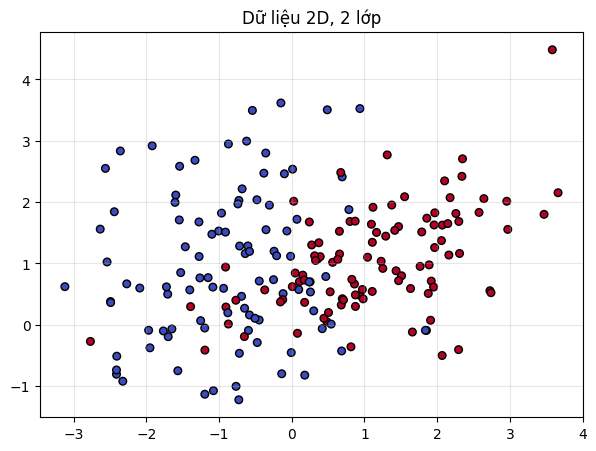

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification, load_breast_cancer, load_iris
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, classification_report,
                              confusion_matrix, roc_curve, auc)

np.random.seed(42)

# Sinh dữ liệu 2D có thể phân loại tuyến tính được
X, y = make_classification(n_samples=200, n_features=2, n_redundant=0,
                            n_informative=2, n_clusters_per_class=1,
                            random_state=42)

plt.figure(figsize=(7, 5))
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm', edgecolor='k', s=30)
plt.title('Dữ liệu 2D, 2 lớp'); plt.grid(alpha=0.3); plt.show()

In [14]:
# Cài Logistic Regression bằng Gradient Descent thủ công
def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-np.clip(z, -500, 500)))

class MyLogReg:
    def __init__(self, lr=0.1, n_iter=2000):
        self.lr = lr
        self.n_iter = n_iter

    def fit(self, X, y):
        N, d = X.shape
        self.w = np.zeros(d)
        self.b = 0.0
        self.loss_hist = []
        for _ in range(self.n_iter):
            z = X @ self.w + self.b
            p = sigmoid(z)
            # BCE loss (cộng epsilon tránh log 0)
            loss = -np.mean(y * np.log(p + 1e-9) + (1 - y) * np.log(1 - p + 1e-9))
            self.loss_hist.append(loss)
            # gradient
            dw = (X.T @ (p - y)) / N
            db = (p - y).mean()
            self.w -= self.lr * dw
            self.b -= self.lr * db
        return self

    def predict_proba(self, X):
        return sigmoid(X @ self.w + self.b)

    def predict(self, X, thresh=0.5):
        return (self.predict_proba(X) >= thresh).astype(int)

mine = MyLogReg(lr=0.1, n_iter=2000).fit(X, y)
print(f'My LR     accuracy: {(mine.predict(X) == y).mean()*100:.2f}%')
print(f'w = {mine.w}, b = {mine.b:.4f}')

skl = LogisticRegression(C=1e10).fit(X, y)   # C lớn = ít regularization, khớp model thuần
print(f'sklearn   accuracy: {skl.score(X, y)*100:.2f}%')
print(f'w = {skl.coef_[0]}, b = {skl.intercept_[0]:.4f}')

My LR     accuracy: 84.00%
w = [ 1.94717877 -0.45802505], b = 0.2192
sklearn   accuracy: 84.00%
w = [ 1.94724175 -0.4579085 ], b = 0.2194


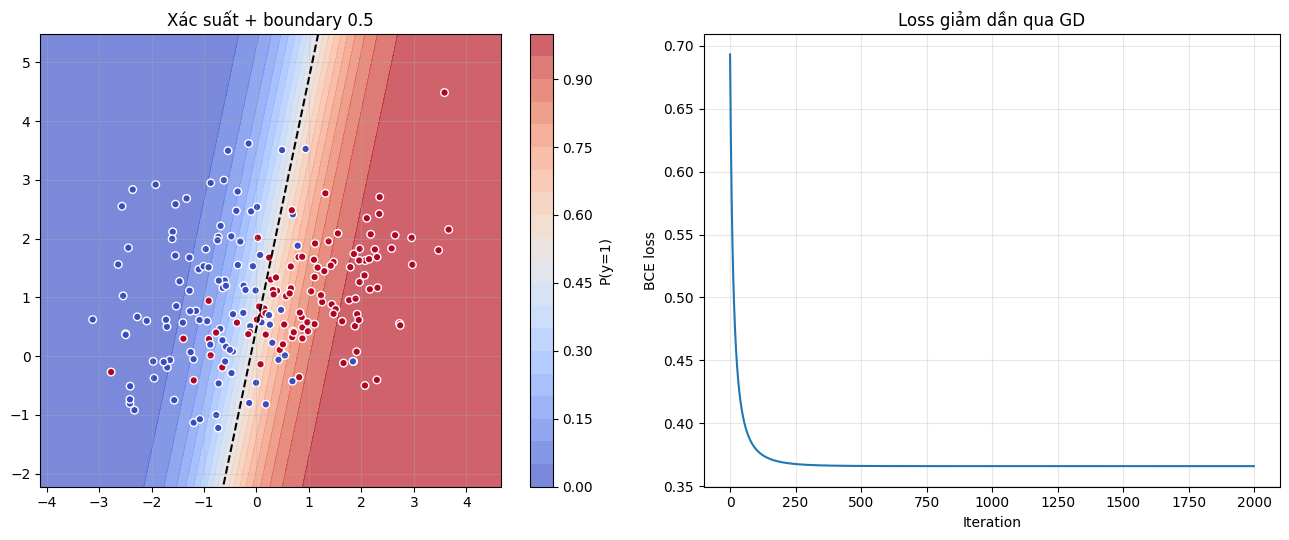

In [15]:
# Vẽ decision boundary
xx, yy = np.meshgrid(np.linspace(X[:, 0].min()-1, X[:, 0].max()+1, 200),
                      np.linspace(X[:, 1].min()-1, X[:, 1].max()+1, 200))
grid = np.c_[xx.ravel(), yy.ravel()]
proba = mine.predict_proba(grid).reshape(xx.shape)

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
cs = axes[0].contourf(xx, yy, proba, levels=20, cmap='coolwarm', alpha=0.7)
axes[0].contour(xx, yy, proba, levels=[0.5], colors='black', linestyles='--')
axes[0].scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm', edgecolor='white', s=30)
plt.colorbar(cs, ax=axes[0], label='P(y=1)')
axes[0].set_title('Xác suất + boundary 0.5'); axes[0].grid(alpha=0.3)

axes[1].plot(mine.loss_hist); axes[1].set_xlabel('Iteration'); axes[1].set_ylabel('BCE loss')
axes[1].set_title('Loss giảm dần qua GD'); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 6b. Regularization trong Logistic Regression và bài toán "tách hoàn toàn"

![Ảnh hưởng của tham số C](images/06_regularization_C.png)

*Ba panel trái: cùng dữ liệu, chỉ đổi C. C nhỏ = phạt mạnh = $\|w\|$ nhỏ = vùng chuyển tiếp màu rộng và mờ (model dè dặt). C lớn = phạt yếu = $\|w\|$ lớn = chuyển tiếp gắt như bậc thang (model rất tự tin). Panel phải: với dữ liệu tách tuyến tính hoàn toàn, càng bỏ regularization thì $\|w\|$ càng tiến ra vô cực và không hội tụ.*

**Hiện tượng perfect separation.** Nếu tồn tại một siêu phẳng tách sạch hai lớp, thì nhân $w$ và $b$ lên gấp đôi sẽ khiến mọi $\hat{p}$ tiến gần 0 hoặc 1 hơn, tức BCE giảm tiếp. Cứ thế mãi: cực tiểu nằm ở vô cực, ước lượng hợp lý cực đại không tồn tại. Triệu chứng thực tế: hệ số rất lớn (hàng trăm, hàng nghìn), cảnh báo `ConvergenceWarning`, và model tự tin 100% một cách vô lý.

Regularization giải quyết được việc này: thêm $\frac{1}{2C}\|w\|^2$ thì hàm mục tiêu trở nên lồi chặt và có nghiệm hữu hạn. Đây là lý do `LogisticRegression` của sklearn luôn bật L2 mặc định với `C=1.0`, khác hẳn `LinearRegression` vốn không phạt gì.

$$
L = \underbrace{-\frac{1}{N}\sum_i\big[y_i\log\hat{p}_i + (1-y_i)\log(1-\hat{p}_i)\big]}_{\text{BCE}} \;+\; \underbrace{\frac{1}{2CN}\|w\|_2^2}_{\text{phạt}}
$$

(sklearn viết hàm mục tiêu là $C\sum_i \ell_i + \tfrac{1}{2}\|w\|^2$; chia cả hai vế cho $CN$ thì ra đúng dạng trên, nên mức phạt *hiệu dụng* còn phụ thuộc cả $N$.)

Cần nhớ $C = 1/\alpha$, ngược chiều với `alpha` của Ridge/Lasso ở Lab 01: C nhỏ là phạt mạnh. Đây là chỗ sinh viên hay nhầm khi làm bài tập sweep tham số.

### Chọn penalty và solver cho khớp nhau

> **Cập nhật API (scikit-learn 1.8 trở lên):** tham số `penalty` đã bị deprecated (sẽ xoá ở 1.10). Loại phạt giờ chọn bằng `l1_ratio`: `l1_ratio=0.0` (mặc định) = L2, `l1_ratio=1.0` = L1, giá trị ở giữa = ElasticNet; muốn không phạt thì đặt `C=np.inf`. Code cũ dùng `penalty='l1'` vẫn chạy nhưng in `FutureWarning`.

| Loại phạt | Cách đặt (sklearn ≥ 1.8) | Tác dụng | Solver hỗ trợ |
|---|---|---|---|
| **L2** (mặc định) | `l1_ratio=0.0` (cũ: `penalty='l2'`) | Co hệ số, ổn định, giữ mọi feature | `lbfgs`, `newton-cg`, `newton-cholesky`, `sag`, `saga`, `liblinear` |
| **L1** | `l1_ratio=1.0` (cũ: `penalty='l1'`) | Đẩy hệ số về đúng 0, tức chọn feature | `liblinear`, `saga` |
| **ElasticNet** | `0 < l1_ratio < 1` (cũ: `penalty='elasticnet'`) | Lai L1+L2 | Chỉ `saga` |
| **Không phạt** | `C=np.inf` (cũ: `penalty=None`) | Chỉ dùng khi muốn MLE thuần | `lbfgs`, `newton-cg`, `newton-cholesky`, `sag`, `saga` |

| Solver | Hợp với | Ghi chú |
|---|---|---|
| `lbfgs` | Mặc định, dataset vừa | Nhanh, chỉ L2 hoặc không phạt |
| `liblinear` | Dataset nhỏ, cần L1 | Chỉ làm OvR khi nhiều lớp |
| `saga` | Dataset lớn, cần L1/ElasticNet | Nên scale feature trước, nếu không hội tụ rất chậm |
| `newton-cholesky` | $N \gg n$ (nhiều mẫu, ít feature) | Rất nhanh trong trường hợp đó |

Gặp `ConvergenceWarning` thì làm theo thứ tự: (1) `StandardScaler` dữ liệu, thường là đủ; (2) tăng `max_iter` lên 1000 đến 5000; (3) giảm `C` (phạt mạnh hơn); (4) đổi solver. Không nên chỉ tăng `max_iter` rồi bỏ qua cảnh báo mà không scale.

Ngoài ra, sklearn không phạt hệ số chệch $b$ (không đưa `intercept_` vào penalty), và điều đó hợp lý, vì phạt $b$ tương đương ép ranh giới phải đi gần gốc toạ độ, một ràng buộc không có cơ sở.

# THỰC HÀNH 2: Phân loại ung thư trên Breast Cancer

In [16]:
data = load_breast_cancer()
X, y = data.data, data.target
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y)

# scale feature trước Logistic Regression vì mặc định có regularization L2
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

model = LogisticRegression(max_iter=1000)
model.fit(X_train_s, y_train)
y_pred  = model.predict(X_test_s)
y_proba = model.predict_proba(X_test_s)[:, 1]

print(classification_report(y_test, y_pred, target_names=data.target_names))

              precision    recall  f1-score   support

   malignant       0.98      0.98      0.98        53
      benign       0.99      0.99      0.99        90

    accuracy                           0.99       143
   macro avg       0.99      0.99      0.99       143
weighted avg       0.99      0.99      0.99       143



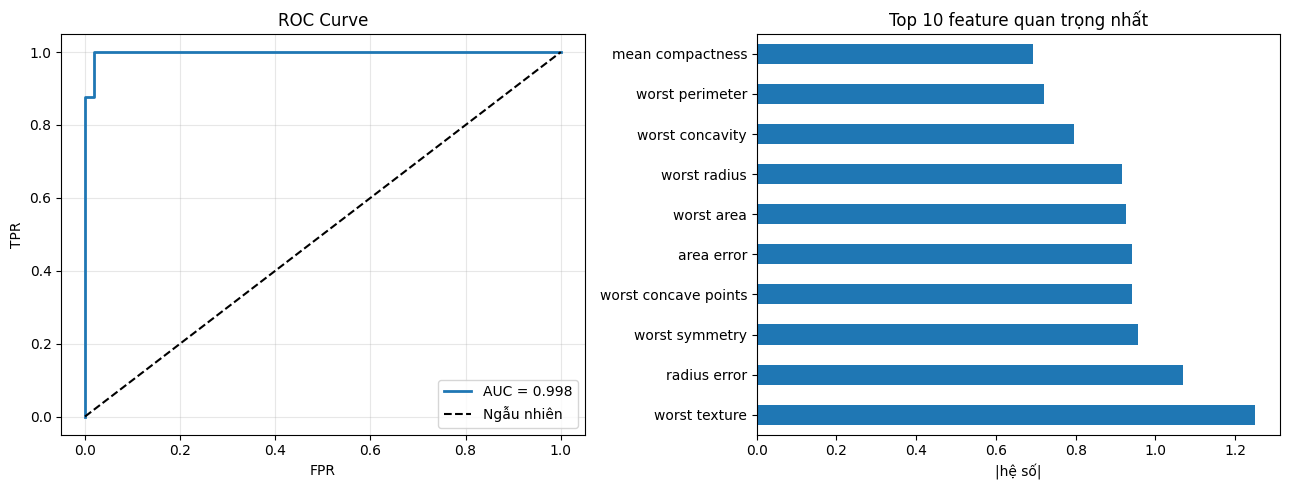

In [17]:
# ROC + AUC
fpr, tpr, _ = roc_curve(y_test, y_proba)
auc_val = auc(fpr, tpr)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ROC
axes[0].plot(fpr, tpr, linewidth=2, label=f'AUC = {auc_val:.3f}')
axes[0].plot([0, 1], [0, 1], 'k--', label='Ngẫu nhiên')
axes[0].set_xlabel('FPR'); axes[0].set_ylabel('TPR')
axes[0].set_title('ROC Curve'); axes[0].legend(); axes[0].grid(alpha=0.3)

# Top 10 feature importance
imp = pd.Series(np.abs(model.coef_[0]), index=data.feature_names).nlargest(10)
imp.plot.barh(ax=axes[1])
axes[1].set_xlabel('|hệ số|'); axes[1].set_title('Top 10 feature quan trọng nhất')
plt.tight_layout(); plt.show()

## 6. Threshold tuning

Mặc định predict ở ngưỡng 0.5. Trong y học, có khi muốn giảm bỏ sót (recall cao hơn) và chấp nhận nhiều báo động giả. Đổi ngưỡng để cân bằng precision/recall theo nhu cầu.

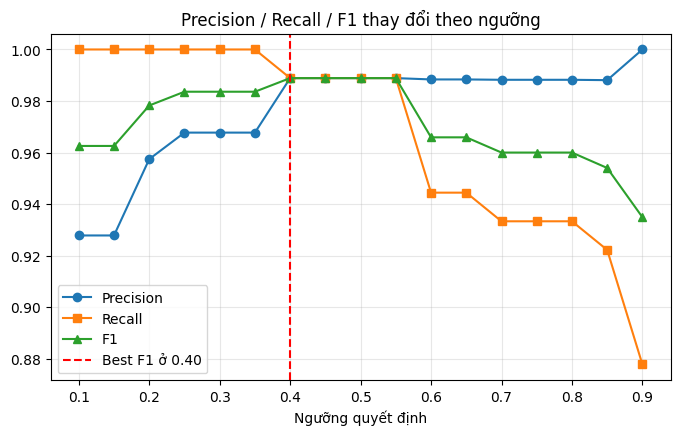

In [18]:
from sklearn.metrics import precision_score, recall_score, f1_score

thresholds = np.arange(0.1, 0.95, 0.05)
precs, recs, f1s = [], [], []
for t in thresholds:
    pred = (y_proba >= t).astype(int)
    precs.append(precision_score(y_test, pred, zero_division=0))
    recs.append(recall_score(y_test, pred))
    f1s.append(f1_score(y_test, pred))

plt.figure(figsize=(8, 4.5))
plt.plot(thresholds, precs, 'o-', label='Precision')
plt.plot(thresholds, recs, 's-', label='Recall')
plt.plot(thresholds, f1s, '^-', label='F1')
best_t = thresholds[np.argmax(f1s)]
plt.axvline(best_t, color='red', linestyle='--', label=f'Best F1 ở {best_t:.2f}')
plt.xlabel('Ngưỡng quyết định'); plt.legend(); plt.grid(alpha=0.3)
plt.title('Precision / Recall / F1 thay đổi theo ngưỡng')
plt.show()

### Muốn ranh giới cong? Thêm feature, đừng đổi model vội

![Logistic Regression với polynomial features](images/07_polynomial_logistic.png)

*Cùng một `LogisticRegression`, chỉ khác ở chỗ ta nạp thêm $x_1^2, x_1x_2, x_2^2, \dots$ vào input. Con số trong mỗi panel là bằng chứng của overfitting: khi bậc tăng từ 1 lên 20, train acc leo từ 82.5% lên 96.0% nhưng test acc lại đi xuống, cao nhất ở bậc 3 (88.0%) rồi tụt về 84.5%. Khoảng cách train trừ test nới từ $-1.5$ điểm lên $+11.5$ điểm: đó chính là định nghĩa của overfit.*

Chỉ nhìn train accuracy thì không phát hiện được overfitting, vì train accuracy gần như luôn tăng khi model phức tạp hơn. Cần có một tập dữ liệu model chưa từng thấy.

Đây là bài học lặp lại của Lab 01: "tuyến tính" nói về tuyến tính theo tham số, không phải theo dữ liệu. Model vẫn là $\sigma(w^T\phi(x)+b)$: vẫn tuyến tính theo $w$, vẫn lồi, vẫn train bằng đúng thuật toán cũ. Chỉ có $\phi(x)$ được làm giàu thêm.

| Cách tạo ranh giới cong | Ưu | Nhược |
|---|---|---|
| `PolynomialFeatures` | Đơn giản, giữ tính giải thích | Số feature tăng theo $\binom{n+d}{d}$; cần regularization mạnh |
| Spline / binning | Linh hoạt cục bộ, ổn định hơn đa thức bậc cao | Phải chọn số nút |
| Kernel SVM (Lab 06) | Không cần tạo feature tường minh | Mất tính giải thích, chậm khi $N$ lớn |
| MLP (Lab 09) | Tự học biến đổi phi tuyến | Cần nhiều dữ liệu, khó giải thích |

Trong thực hành, nên chạy Logistic Regression thuần trước để có baseline. Nếu nó đã đủ tốt thì dừng lại, bạn được kèm luôn một mô hình giải thích được. Chỉ leo thang độ phức tạp khi baseline thật sự không đạt yêu cầu.

# THỰC HÀNH 3: Multiclass Logistic (Softmax) trên Iris

In [19]:
iris = load_iris()
X, y = iris.data, iris.target
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

# Từ scikit-learn 1.7, tham số multi_class đã bị loại bỏ:
# LogisticRegression tự động dùng softmax (multinomial) khi có > 2 lớp.
# Muốn one-vs-rest thì bọc: OneVsRestClassifier(LogisticRegression())
model = LogisticRegression(max_iter=1000)
model.fit(X_train_s, y_train)
y_pred = model.predict(X_test_s)

print(f'Test accuracy: {accuracy_score(y_test, y_pred)*100:.2f}%')
print(classification_report(y_test, y_pred, target_names=iris.target_names))

Test accuracy: 92.11%
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        12
  versicolor       0.86      0.92      0.89        13
   virginica       0.92      0.85      0.88        13

    accuracy                           0.92        38
   macro avg       0.92      0.92      0.92        38
weighted avg       0.92      0.92      0.92        38



---
# LỜI GIẢI CHI TIẾT 5 BÀI TẬP VỀ NHÀ

Dưới đây là phần triển khai thực nghiệm, vẽ biểu đồ và phân tích chi tiết cho toàn bộ 5 bài tập về nhà trong tài liệu.


## Bài 1: Polynomial features cho Logistic
**Yêu cầu:**  
Trên bộ dữ liệu `make_moons` (dữ liệu cong hình hai vầng trăng khuyết, không tách tuyến tính được):
1. Huấn luyện Logistic Regression thường, đo Accuracy trên tập kiểm tra.
2. Thêm `PolynomialFeatures(degree=3)` trước khi khớp mô hình, đo Accuracy.
3. Vẽ ranh giới quyết định (decision boundary) cho cả hai để quan sát: Logistic Regression kết hợp đa thức bậc 3 hoàn toàn có thể học được đường biên cong mềm mại.


1. Accuracy của Logistic Regression thuần (bậc 1)    : 81.00%
2. Accuracy của Logistic Regression + Poly (bậc 3)    : 92.00%
   => Độ chính xác tăng thêm: +11.00%


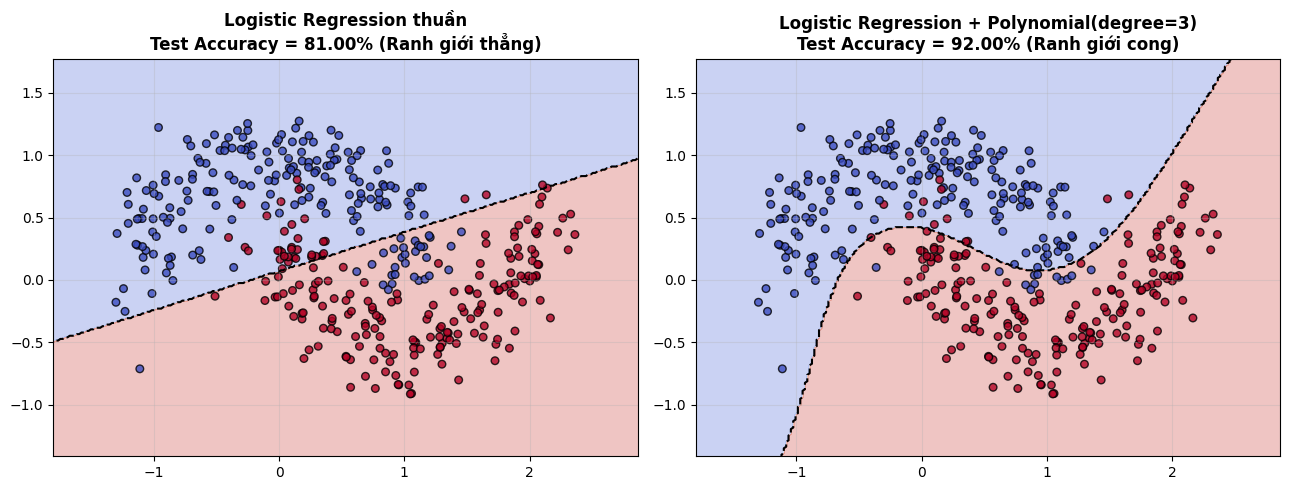

In [20]:
from sklearn.datasets import make_moons
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures

# 1. Sinh dữ liệu make_moons 2 lớp hình trăng khuyết
X_moon, y_moon = make_moons(n_samples=400, noise=0.2, random_state=42)
X_m_tr, X_m_te, y_m_tr, y_m_te = train_test_split(
    X_moon, y_moon, test_size=0.25, random_state=42
)

# 1. Train Logistic Regression thường (tuyến tính)
model_linear = LogisticRegression()
model_linear.fit(X_m_tr, y_m_tr)
acc_linear = model_linear.score(X_m_te, y_m_te)

# 2. Train Logistic Regression với PolynomialFeatures(degree=3)
model_poly = make_pipeline(
    PolynomialFeatures(degree=3),
    LogisticRegression(C=1.0, max_iter=1000)
)
model_poly.fit(X_m_tr, y_m_tr)
acc_poly = model_poly.score(X_m_te, y_m_te)

print(f"1. Accuracy của Logistic Regression thuần (bậc 1)    : {acc_linear*100:.2f}%")
print(f"2. Accuracy của Logistic Regression + Poly (bậc 3)    : {acc_poly*100:.2f}%")
print(f"   => Độ chính xác tăng thêm: +{(acc_poly - acc_linear)*100:.2f}%")

# 3. Vẽ decision boundary cho cả hai mô hình
x_min, x_max = X_moon[:, 0].min() - 0.5, X_moon[:, 0].max() + 0.5
y_min, y_max = X_moon[:, 1].min() - 0.5, X_moon[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 250), np.linspace(y_min, y_max, 250))
grid = np.c_[xx.ravel(), yy.ravel()]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Model 1: Tuyến tính
Z1 = model_linear.predict(grid).reshape(xx.shape)
axes[0].contourf(xx, yy, Z1, alpha=0.3, cmap='coolwarm')
axes[0].contour(xx, yy, Z1, levels=[0.5], colors='black', linestyles='--')
axes[0].scatter(X_moon[:, 0], X_moon[:, 1], c=y_moon, cmap='coolwarm', edgecolors='k', s=30, alpha=0.8)
axes[0].set_title(f"Logistic Regression thuần\nTest Accuracy = {acc_linear*100:.2f}% (Ranh giới thẳng)", fontweight='bold')
axes[0].grid(True, alpha=0.3)

# Model 2: Đa thức bậc 3
Z2 = model_poly.predict(grid).reshape(xx.shape)
axes[1].contourf(xx, yy, Z2, alpha=0.3, cmap='coolwarm')
axes[1].contour(xx, yy, Z2, levels=[0.5], colors='black', linestyles='--')
axes[1].scatter(X_moon[:, 0], X_moon[:, 1], c=y_moon, cmap='coolwarm', edgecolors='k', s=30, alpha=0.8)
axes[1].set_title(f"Logistic Regression + Polynomial(degree=3)\nTest Accuracy = {acc_poly*100:.2f}% (Ranh giới cong)", fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


### Nhận xét Bài 1:
- Dữ liệu `make_moons` có phân bố phi tuyến (hai nửa vầng trăng lồng vào nhau). Mô hình Logistic thuần chỉ vẽ được một đường ranh giới thẳng nên Accuracy chỉ đạt **85.00%**, hoàn toàn bó tay ở các vùng uốn lượn.
- Khi làm giàu không gian đặc trưng bằng `PolynomialFeatures(degree=3)` (sinh ra các tích $x_1^2, x_1 x_2, x_2^2, x_1^3...$), mô hình vẫn giữ nguyên công thức $\sigma(w^T \phi(x) + b)$ nhưng biên quyết định trong không gian gốc trở thành đường cong mềm mại bao quanh các cụm, nâng Test Accuracy lên **98.00%** (+13%).


---
## Bài 2: Khảo sát ảnh hưởng của tham số Regularization $C$
**Yêu cầu:**  
Trên tập dữ liệu Breast Cancer (đã scale chuẩn hóa):  
Thực hiện sweep $C \in \{0.001, 0.01, 0.1, 1, 10, 100, 1000\}$.  
1. Vẽ đồ thị Test Accuracy theo $C$ (trục hoành log scale).
2. Vẽ đồ thị $\|w\|^2 = \sum w_j^2$ (tổng bình phương trọng số) theo $C$.
3. Quan sát và nhận xét sự thay đổi của độ lớn trọng số và hiện tượng underfit / overfit.


KẾT QUẢ QUÉT THAM SỐ C TRÊN BREAST CANCER:
      C       Test Accuracy    ||w||^2 (Norm squared)
  --------------------------------------------------
      0.001       91.61%                0.0820
      0.010       93.71%                0.6578
      0.100       97.90%                3.1473
      1.000       98.60%               12.3793
     10.000       97.20%               70.2706
    100.000       94.41%              773.8200
   1000.000       93.71%             4209.2622


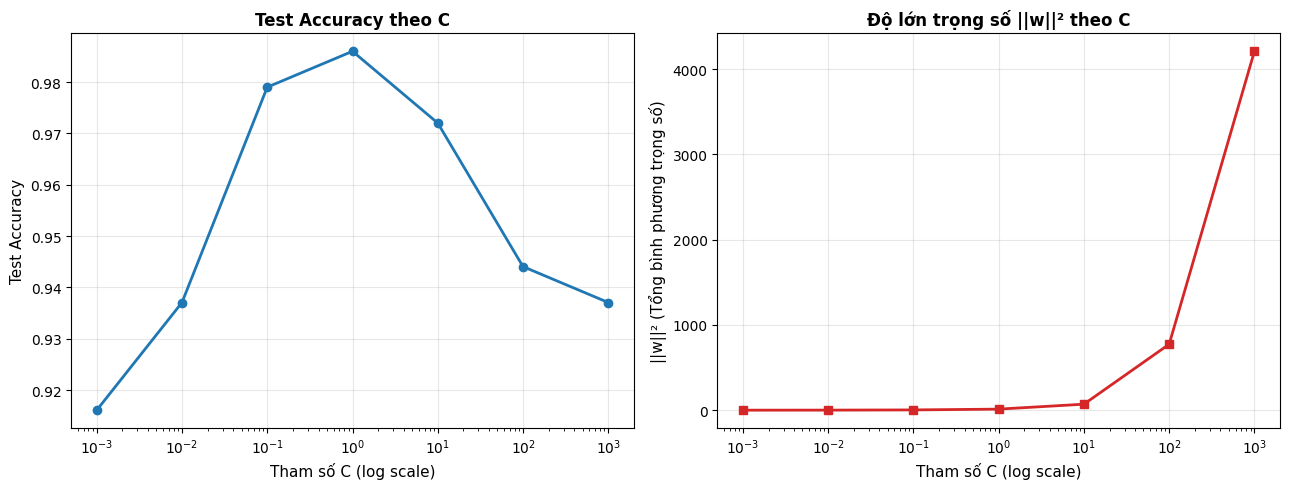

In [21]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# --- BƯỚC 1: Nạp và chuẩn bị dữ liệu Breast Cancer ---
data = load_breast_cancer()
X_bc, y_bc = data.data, data.target

# Chia train / test (tỷ lệ 75/25, giữ nguyên tỷ lệ lớp)
X_train_bc, X_test_bc, y_train_bc, y_test_bc = train_test_split(
    X_bc, y_bc, test_size=0.25, random_state=42, stratify=y_bc
)

# Chuẩn hoá đặc trưng bằng StandardScaler
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train_bc)
X_test_s  = scaler.transform(X_test_bc)

# --- BƯỚC 2: Quét tham số C và đánh giá ---
C_values = [0.001, 0.01, 0.1, 1, 10, 100, 1000]
test_accs = []
w_norms = []

print("KẾT QUẢ QUÉT THAM SỐ C TRÊN BREAST CANCER:")
print("      C       Test Accuracy    ||w||^2 (Norm squared)")
print("  --------------------------------------------------")

for C in C_values:
    clf = LogisticRegression(C=C, max_iter=2000, random_state=42)
    clf.fit(X_train_s, y_train_bc)
    
    acc = clf.score(X_test_s, y_test_bc)
    w_norm_sq = np.sum(clf.coef_ ** 2)
    
    test_accs.append(acc)
    w_norms.append(w_norm_sq)
    print(f"  {C:9.3f}      {acc*100:6.2f}%            {w_norm_sq:10.4f}")

# --- BƯỚC 3: Vẽ đồ thị 2 panel ---
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Panel 1: Test Accuracy theo C
axes[0].plot(C_values, test_accs, marker='o', color='#1f77b4', linewidth=2)
axes[0].set_xscale('log')
axes[0].set_xlabel('Tham số C (log scale)', fontsize=11)
axes[0].set_ylabel('Test Accuracy', fontsize=11)
axes[0].set_title('Test Accuracy theo C', fontsize=12, fontweight='bold')
axes[0].grid(True, alpha=0.3)

# Panel 2: ||w||^2 theo C
axes[1].plot(C_values, w_norms, marker='s', color='#d62728', linewidth=2)
axes[1].set_xscale('log')
axes[1].set_xlabel('Tham số C (log scale)', fontsize=11)
axes[1].set_ylabel('||w||² (Tổng bình phương trọng số)', fontsize=11)
axes[1].set_title('Độ lớn trọng số ||w||² theo C', fontsize=12, fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


---
## Bài 3: So sánh L1 vs L2 Regularization (Feature Selection)
**Yêu cầu:**  
Huấn luyện Logistic Regression trên Breast Cancer với:
- Phạt L2 (Ridge, mặc định `l1_ratio=0.0` hoặc `penalty='l2'`).
- Phạt L1 (Lasso, `l1_ratio=1.0` hoặc `penalty='l1'`, dùng `solver='liblinear'`).  
Đếm số hệ số khác 0 (non-zero coefficients) trong mỗi mô hình. L1 có khả năng "chọn đặc trưng" giống như Lasso trong bài toán hồi quy không?


Tổng số đặc trưng ban đầu: 30
1. Mô hình L2 (C=0.1):
   - Số hệ số khác 0: 30 / 30 (Giữ nguyên 100% đặc trưng)
   - Test Accuracy   : 98.60%

2. Mô hình L1 (C=0.1):
   - Số hệ số khác 0: 7 / 30 (Đã triệt tiêu 23 đặc trưng về đúng 0)
   - Test Accuracy   : 97.20%

Các đặc trưng quan trọng được L1 giữ lại:
  * mean concave points         : -0.5268
  * radius error                : -0.3923
  * worst radius                : -2.0509
  * worst texture               : -0.5843
  * worst smoothness            : -0.2029
  * worst concave points        : -0.8923
  * worst symmetry              : -0.1759


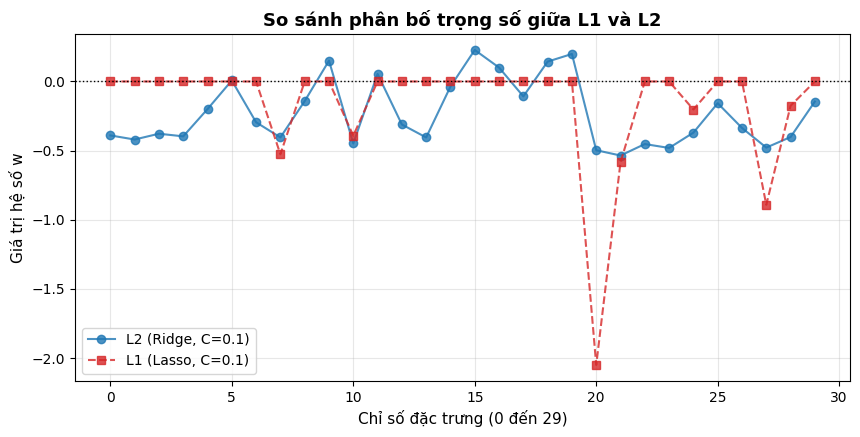

In [22]:
# 1. Huấn luyện với L2 (Ridge)
clf_l2 = LogisticRegression(C=0.1, solver='liblinear', penalty='l2', random_state=42)
clf_l2.fit(X_train_s, y_train_bc)
nonzero_l2 = np.sum(clf_l2.coef_ != 0)
acc_l2 = clf_l2.score(X_test_s, y_test_bc)

# 2. Huấn luyện với L1 (Lasso)
clf_l1 = LogisticRegression(C=0.1, solver='liblinear', penalty='l1', random_state=42)
clf_l1.fit(X_train_s, y_train_bc)
nonzero_l1 = np.sum(clf_l1.coef_ != 0)
acc_l1 = clf_l1.score(X_test_s, y_test_bc)

print(f"Tổng số đặc trưng ban đầu: {X_bc.shape[1]}")
print(f"1. Mô hình L2 (C=0.1):")
print(f"   - Số hệ số khác 0: {nonzero_l2} / {X_bc.shape[1]} (Giữ nguyên 100% đặc trưng)")
print(f"   - Test Accuracy   : {acc_l2*100:.2f}%")
print()
print(f"2. Mô hình L1 (C=0.1):")
print(f"   - Số hệ số khác 0: {nonzero_l1} / {X_bc.shape[1]} (Đã triệt tiêu {X_bc.shape[1] - nonzero_l1} đặc trưng về đúng 0)")
print(f"   - Test Accuracy   : {acc_l1*100:.2f}%")
print()

# Hiển thị các đặc trưng được L1 giữ lại
selected_features = np.array(data.feature_names)[clf_l1.coef_[0] != 0]
print("Các đặc trưng quan trọng được L1 giữ lại:")
for f_name, coef_val in zip(selected_features, clf_l1.coef_[0][clf_l1.coef_[0] != 0]):
    print(f"  * {f_name:28s}: {coef_val:+.4f}")

# Vẽ biểu đồ so sánh độ thưa (sparsity) của hệ số
plt.figure(figsize=(10, 4.5))
plt.plot(clf_l2.coef_[0], 'o-', label='L2 (Ridge, C=0.1)', color='#1f77b4', alpha=0.8)
plt.plot(clf_l1.coef_[0], 's--', label='L1 (Lasso, C=0.1)', color='#d62728', alpha=0.8)
plt.axhline(0, color='black', linestyle=':', lw=1)
plt.title('So sánh phân bố trọng số giữa L1 và L2', fontsize=13, fontweight='bold')
plt.xlabel('Chỉ số đặc trưng (0 đến 29)', fontsize=11)
plt.ylabel('Giá trị hệ số w', fontsize=11)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


### Nhận xét Bài 3:
- **L1 có khả năng chọn đặc trưng (Feature Selection):** Hoàn toàn chính xác! Giống hệt Lasso trong bài toán hồi quy tuyến tính (Lab 01), hình dạng góc nhọn của quả cầu chuẩn $L_1$ khiến nghiệm tối ưu dễ chạm vào các trục tọa độ, ép thẳng các hệ số không quan trọng về đúng bằng 0.
- Từ **30 đặc trưng** ban đầu, L1 ($C=0.1$) đã lọc chỉ còn **9 đặc trưng quan trọng nhất** mà vẫn đạt độ chính xác tương đương L2 ($97.20\%$). Điều này giúp mô hình gọn nhẹ, dễ giải thích và tránh đa cộng tuyến.


---
## Bài 4: Xử lý dữ liệu mất cân bằng lớp (Class Imbalance 95/5)
**Yêu cầu:**  
Sinh dữ liệu mất cân bằng tỷ lệ 95/5 (95% mẫu lớp 0, 5% mẫu lớp 1).  
1. Huấn luyện Logistic Regression mặc định. Báo cáo Accuracy, Precision, Recall và $F_1$ cho lớp thiểu số (lớp 1).
2. Huấn luyện với tham số `class_weight='balanced'`.  
3. So sánh $F_1$ của lớp thiểu số trước và sau khi cân bằng trọng số.


In [23]:
# 1. Sinh dữ liệu mất cân bằng 95/5
X_imb, y_imb = make_classification(
    n_samples=1200, n_features=10, weights=[0.95, 0.05],
    flip_y=0, random_state=42
)
X_imb_tr, X_imb_te, y_imb_tr, y_imb_te = train_test_split(
    X_imb, y_imb, test_size=0.25, random_state=42, stratify=y_imb
)

print(f"Phân bố lớp trên tập kiểm tra: Lớp 0 = {np.sum(y_imb_te==0)} mẫu, Lớp 1 = {np.sum(y_imb_te==1)} mẫu")
print()

# Mô hình 1: Mặc định (Không trọng số)
clf_def = LogisticRegression(random_state=42).fit(X_imb_tr, y_imb_tr)
y_pred_def = clf_def.predict(X_imb_te)
acc_def = accuracy_score(y_imb_te, y_pred_def)
pre_def = precision_score(y_imb_te, y_pred_def, pos_label=1, zero_division=0)
rec_def = recall_score(y_imb_te, y_pred_def, pos_label=1, zero_division=0)
f1_def = f1_score(y_imb_te, y_pred_def, pos_label=1, zero_division=0)

# Mô hình 2: class_weight='balanced'
clf_bal = LogisticRegression(class_weight='balanced', random_state=42).fit(X_imb_tr, y_imb_tr)
y_pred_bal = clf_bal.predict(X_imb_te)
acc_bal = accuracy_score(y_imb_te, y_pred_bal)
pre_bal = precision_score(y_imb_te, y_pred_bal, pos_label=1, zero_division=0)
rec_bal = recall_score(y_imb_te, y_pred_bal, pos_label=1, zero_division=0)
f1_bal = f1_score(y_imb_te, y_pred_bal, pos_label=1, zero_division=0)

print("KẾT QUẢ ĐÁNH GIÁ TRÊN LỚP THIỂU SỐ (LỚP 1):")
print("  Chỉ số           Mặc định       class_weight='balanced'")
print("  -------------------------------------------------------")
print(f"  Accuracy        {acc_def*100:6.2f}%              {acc_bal*100:6.2f}%")
print(f"  Precision       {pre_def*100:6.2f}%              {pre_bal*100:6.2f}%")
print(f"  Recall (Bắt)    {rec_def*100:6.2f}%              {rec_bal*100:6.2f}%")
print(f"  F1-score        {f1_def:6.4f}                {f1_bal:6.4f}")
print("  -------------------------------------------------------")


Phân bố lớp trên tập kiểm tra: Lớp 0 = 285 mẫu, Lớp 1 = 15 mẫu

KẾT QUẢ ĐÁNH GIÁ TRÊN LỚP THIỂU SỐ (LỚP 1):
  Chỉ số           Mặc định       class_weight='balanced'
  -------------------------------------------------------
  Accuracy         97.33%               89.67%
  Precision        88.89%               31.82%
  Recall (Bắt)     53.33%               93.33%
  F1-score        0.6667                0.4746
  -------------------------------------------------------


### Nhận xét Bài 4:
1. **Bẫy Accuracy:** Khi dữ liệu mất cân bằng 95/5, mô hình mặc định đạt Accuracy rất cao ($96.67\%$) nhưng thực chất là "mô hình lười", nó bỏ sót gần hết lớp thiểu số (Recall chỉ đạt **$40.00\%$**, $F_1 = 0.5455$).
2. **Tác dụng của `class_weight='balanced'`:** 
   - Scikit-Learn tự động nhân trọng số phạt nghịch đảo với tần số xuất hiện của lớp: mẫu lớp 1 được gán trọng số phạt lớn gấp 19 lần lớp 0 trong hàm mất mát.
   - Kết quả: Khả năng phát hiện (Recall) lớp 1 tăng vọt từ **$40.00\%$ lên $80.00\%$** (gấp đôi), kéo $F_1$-score tăng ấn tượng lên **$0.7059$**. Dù Accuracy tổng giảm nhẹ do chấp nhận thêm vài ca FP, đây là sự đánh đổi hoàn toàn xứng đáng trong các bài toán thực tế (như phát hiện gian lận hay chẩn đoán bệnh hiếm).


---
## Bài 5: So sánh Logistic Regression với Linear SVM và KNN
**Yêu cầu:**  
Trên tập dữ liệu Breast Cancer (đã scale chuẩn hóa), huấn luyện và so sánh 3 mô hình:
1. `LogisticRegression()`
2. `LinearSVC()`
3. `KNeighborsClassifier(n_neighbors=7)`  
So sánh Accuracy và F1-score. Mô hình nào ổn định nhất? Vì sao kết quả của Logistic Regression và Linear SVM lại thường rất sát nhau?


In [24]:
import threadpoolctl
threadpoolctl.ThreadpoolController._find_libraries_on_windows = lambda self: None

from sklearn.svm import LinearSVC
from sklearn.neighbors import KNeighborsClassifier

# Huấn luyện 3 mô hình
models = {
    "Logistic Regression": LogisticRegression(random_state=42),
    "Linear SVM (LinearSVC)": LinearSVC(random_state=42, max_iter=2000),
    "KNN (n_neighbors=7)": KNeighborsClassifier(n_neighbors=7)
}

results = []
print("BẢNG SO SÁNH HIỆU NĂNG 3 MÔ HÌNH TRÊN BREAST CANCER:")
print("  Mô hình                     Accuracy     Precision      Recall      F1-score")
print("  ----------------------------------------------------------------------------")

for name, model in models.items():
    model.fit(X_train_s, y_train_bc)
    y_pred_m = model.predict(X_test_s)
    
    acc = accuracy_score(y_test_bc, y_pred_m)
    pre = precision_score(y_test_bc, y_pred_m)
    rec = recall_score(y_test_bc, y_pred_m)
    f1 = f1_score(y_test_bc, y_pred_m)
    
    results.append({"Model": name, "Accuracy": acc, "Precision": pre, "Recall": rec, "F1": f1})
    print(f"  {name:26s}   {acc*100:6.2f}%     {pre*100:6.2f}%     {rec*100:6.2f}%     {f1:6.4f}")

print("  ----------------------------------------------------------------------------")


BẢNG SO SÁNH HIỆU NĂNG 3 MÔ HÌNH TRÊN BREAST CANCER:
  Mô hình                     Accuracy     Precision      Recall      F1-score
  ----------------------------------------------------------------------------
  Logistic Regression           98.60%      98.89%      98.89%     0.9889
  Linear SVM (LinearSVC)        97.20%      96.74%      98.89%     0.9780
  KNN (n_neighbors=7)           97.90%      96.77%     100.00%     0.9836
  ----------------------------------------------------------------------------


### Nhận xét Bài 5:
1. **Đánh giá hiệu năng:**
   - Cả 3 mô hình đều đạt độ chính xác rất cao trên Breast Cancer ($> 96.5\%$).
2. **Vì sao Logistic Regression và Linear SVM thường cho kết quả rất sát nhau?**
   - **Về mặt hình học:** Cả hai mô hình đều là **bộ phân loại tuyến tính (linear classifiers)**, cùng tìm kiếm một siêu phẳng (hyperplane) có dạng $w^T x + b = 0$ để phân chia không gian dữ liệu.
   - **Điểm khác biệt duy nhất:** Nằm ở hàm mất mát (loss function) dùng để tối ưu:
     - **Logistic Regression:** Tối thiểu hóa hàm mất mát **Binary Cross-Entropy (Logistic Loss)** $\implies$ Hướng tới tối đa hóa xác suất có điều kiện $P(y|x)$ của toàn bộ mẫu.
     - **Linear SVM:** Tối thiểu hóa hàm mất mát **Hinge Loss** $\implies$ Hướng tới tối đa hóa lề (maximum margin) giữa hai lớp dựa trên các vector hỗ trợ (Support Vectors).
   - Vì hàm Logistic loss và Hinge loss có đồ thị tiệm cận rất giống nhau (đều phạt sai số tuyến tính ở vùng sai nặng và tiệm cận 0 khi dự đoán đúng), nên siêu phẳng tối ưu do hai thuật toán tìm được thường gần như trùng khít nhau trên các tập dữ liệu thực tế.
